# Smoothing della curva CH2 di un punto

Prende **un punto** di un run (`punto_NNN_....csv` e il registro `griglia.csv`), individua la zona della scansione da CH1 (dal primo campione sopra `V_INIZIO_V` al massimo della rampa) e smussa CH2 in quella zona con il metodo scelto in `METODO`:

- `"savgol"`: filtro di Savitzky-Golay (`scipy.signal.savgol_filter`), segue bene i picchi delle campane;
- `"gaussiano"`: filtro gaussiano (`scipy.ndimage.gaussian_filter1d`);
- `"media_mobile"`: media mobile (`scipy.ndimage.uniform_filter1d`).

Passaggi: (opzionale) apertura per togliere i picchi spuri positivi, riduzione a `N_PUNTI` con la media a blocchi (altrimenti i filtri su milioni di campioni sono lentissimi), smoothing. La cella 3 stampa il max - min dopo ogni passaggio e la cella 4 mostra le curve.

Le larghezze dei filtri (`SAVGOL_FINESTRA`, `GAUSS_SIGMA`, `MEDIA_FINESTRA`) sono in **punti della curva ridotta**: valori più grandi smussano di più ma appiattiscono le campane.

In [1]:
# Cella 1 - impostazioni
import csv
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d, maximum_filter1d, minimum_filter1d, uniform_filter1d
from scipy.signal import savgol_filter

try:
    import pandas as pd
except ImportError:
    pd = None

CARTELLA_RUN = "2026-10-06/run_006"          # <-- SCRIVI QUI la cartella del run, es. "2026-10-05/run_002" (relativa al notebook) o un percorso completo
PUNTO = 0                  # indice del punto da smussare (colonna "indice" di griglia.csv)

V_INIZIO_V = 0.9           # CH1 sopra questo valore = inizio della scansione (livello del trigger)
TOLLERANZA_FINE_V = 0.3    # la rampa e' finita quando CH1 e' a meno di questo dal suo massimo

PRE_APERTURA = True        # True: toglie i picchi spuri POSITIVI stretti (minimo mobile + massimo mobile) prima dello smoothing
APERTURA_CAMPIONI = 50     # larghezza dell'apertura in campioni: poco piu' larga dei picchi e molto piu' stretta delle campane

N_PUNTI = 20000            # la zona viene ridotta a questo numero di punti (media a blocchi) prima dello smoothing

METODO = "savgol"          # "savgol" | "gaussiano" | "media_mobile"
SAVGOL_FINESTRA = 201      # punti (dispari)
SAVGOL_ORDINE = 3
GAUSS_SIGMA = 40           # punti
MEDIA_FINESTRA = 101       # punti

In [3]:
# Cella 2 - carica il punto e trova la zona della scansione
def carica_canali(percorso):
    if pd is not None:
        df = pd.read_csv(percorso, dtype=np.float32)
        return df["CH1"].to_numpy(), df["CH2"].to_numpy()
    dati = np.loadtxt(percorso, delimiter=",", skiprows=1, dtype=np.float32)
    return dati[:, 0], dati[:, 1]


def zona_scansione(ch1):
    sopra = np.flatnonzero(ch1 > V_INIZIO_V)
    if sopra.size == 0:
        return None
    i0 = int(sopra[0])
    fine = np.flatnonzero(ch1[i0:] >= ch1.max() - TOLLERANZA_FINE_V)
    i1 = i0 + int(fine[0])
    return (i0, i1) if i1 > i0 else None


if not CARTELLA_RUN.strip():
    raise ValueError("Scrivi in cella 1 la cartella del run in CARTELLA_RUN, es. '2026-10-05/run_002'")
run_folder = os.path.abspath(CARTELLA_RUN)
with open(os.path.join(run_folder, "griglia.csv"), newline="") as f:
    registro = list(csv.DictReader(f))
riga = next((r for r in registro if int(r["indice"]) == PUNTO), None)
if riga is None:
    raise ValueError(f"Punto {PUNTO} non presente nel registro ({len(registro)} punti)")

ch1, ch2 = carica_canali(os.path.join(run_folder, riga["file"]))
zona = zona_scansione(ch1)
if zona is None:
    raise RuntimeError(f"Nessuna scansione trovata in CH1 (mai sopra {V_INIZIO_V} V)")
i0, i1 = zona
print(f"Punto {PUNTO}: X={riga['x_mm']} mm, Y={riga['y_mm']} mm | {riga['file']}")
print(f"Zona della scansione: campioni {i0}..{i1} ({i1 - i0 + 1} campioni, {(i1 - i0) / len(ch1) * 100:.0f}% del record)")

Punto 0: X=92.2940 mm, Y=146.5540 mm | punto_000_x92.294_y146.554.csv
Zona della scansione: campioni 8917..67449 (58533 campioni, 59% del record)


In [5]:
# Cella 3 - apertura (opzionale) -> riduzione a blocchi -> smoothing
seg = ch2[i0:i1 + 1].astype(np.float32)
print(f"max - min grezzo (con i picchi)      : {seg.max() - seg.min():.4f} V")

if PRE_APERTURA:
    w = max(3, int(APERTURA_CAMPIONI))
    seg = maximum_filter1d(minimum_filter1d(seg, size=w, mode="nearest"), size=w, mode="nearest")
    print(f"max - min dopo l'apertura            : {seg.max() - seg.min():.4f} V")

n = max(1, len(seg) // int(N_PUNTI))
k = len(seg) // n
ridotta = seg[:k * n].astype(np.float64).reshape(k, n).mean(axis=1)
asse_ridotto = i0 + (np.arange(k) + 0.5) * n
print(f"curva ridotta a {k} punti ({n} campioni per blocco)")

if METODO == "savgol":
    w = int(SAVGOL_FINESTRA) | 1                       # forza dispari
    w = min(w, k if k % 2 == 1 else k - 1)              # non piu' lunga della curva
    liscia = savgol_filter(ridotta, window_length=w, polyorder=int(SAVGOL_ORDINE), mode="nearest")
elif METODO == "gaussiano":
    liscia = gaussian_filter1d(ridotta, sigma=float(GAUSS_SIGMA), mode="nearest")
elif METODO == "media_mobile":
    liscia = uniform_filter1d(ridotta, size=int(MEDIA_FINESTRA), mode="nearest")
else:
    raise ValueError("METODO deve essere 'savgol', 'gaussiano' o 'media_mobile'")

print(f"max - min curva ridotta              : {ridotta.max() - ridotta.min():.4f} V")
print(f"max - min dopo lo smoothing ({METODO}): {liscia.max() - liscia.min():.4f} V")

max - min grezzo (con i picchi)      : 0.0300 V
max - min dopo l'apertura            : 0.0208 V
curva ridotta a 29266 punti (2 campioni per blocco)
max - min curva ridotta              : 0.0164 V
max - min dopo lo smoothing (savgol): 0.0128 V


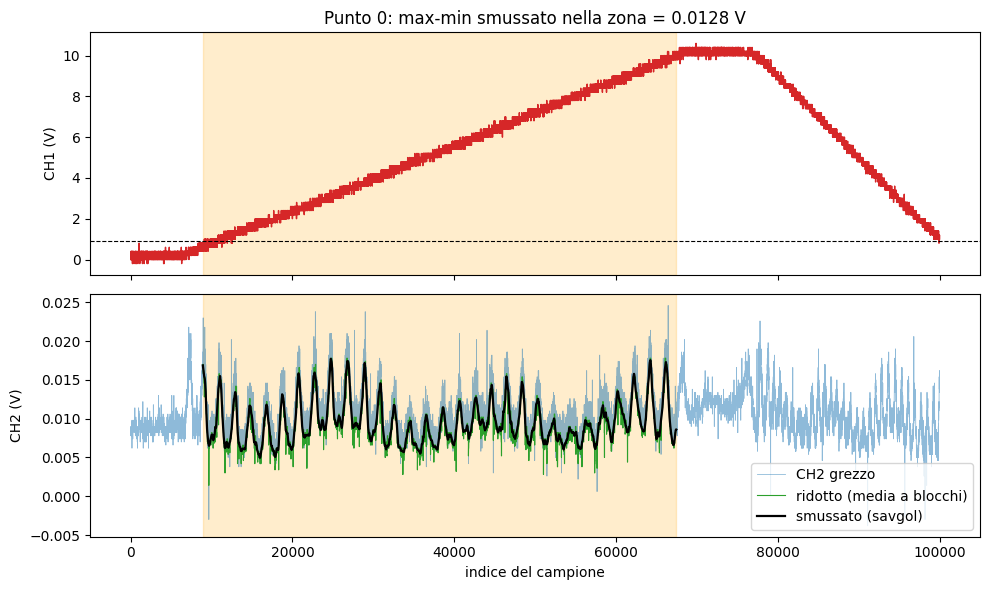

In [6]:
# Cella 4 - confronto grafico
passo = max(1, len(ch2) // 20000)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
a1.plot(np.arange(len(ch1))[::passo], ch1[::passo], color="tab:red", lw=1)
a1.axhline(V_INIZIO_V, color="k", ls="--", lw=0.8)
a1.set_ylabel("CH1 (V)")
a2.plot(np.arange(len(ch2))[::passo], ch2[::passo], color="tab:blue", lw=0.6, alpha=0.5, label="CH2 grezzo")
a2.plot(asse_ridotto, ridotta, color="tab:green", lw=0.8, label="ridotto (media a blocchi)")
a2.plot(asse_ridotto, liscia, color="k", lw=1.6, label=f"smussato ({METODO})")
a2.set_ylabel("CH2 (V)")
a2.set_xlabel("indice del campione")
a2.legend(loc="best")
for a in (a1, a2):
    a.axvspan(i0, i1, color="orange", alpha=0.2)
a1.set_title(f"Punto {PUNTO}: max-min smussato nella zona = {liscia.max() - liscia.min():.4f} V")
plt.tight_layout()
plt.show()